In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns 
import matplotlib.pyplot as plt 

In [2]:
df = pd.read_csv("../data/credit_card_fraud.csv")
df.head()

,transaction_id,transaction_amount,transaction_time,merchant_category,customer_age,customer_location,device_type,card_type,transaction_type,previous_fraud_count,avg_transaction_amount,account_age_days,num_transactions_24h,num_transactions_7d,is_international,is_weekend,risk_score,fraud
0,1,46.93,17266.0,NaN,48.0,city_C,tablet,credit,offline,1.0,90.96,3342.0,2.0,14.0,1.0,0.0,0.816,0
1,2,301.01,86328.0,electronics,58.0,city_A,tablet,debit,offline,0.0,126.38,3157.0,4.0,20.0,0.0,1.0,0.173,0
2,3,131.67,85988.0,grocery,24.0,city_A,desktop,debit,online,NaN,187.89,1163.0,4.0,14.0,0.0,0.0,0.378,0
3,4,91.29,43526.0,travel,40.0,city_A,mobile,credit,offline,0.0,84.32,3150.0,4.0,NaN,0.0,0.0,0.847,0
4,5,16.96,11889.0,food,41.0,city_C,tablet,credit,NaN,1.0,138.83,1808.0,3.0,15.0,0.0,NaN,0.799,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          3000 non-null   int64  
 1   transaction_amount      2850 non-null   float64
 2   transaction_time        2850 non-null   float64
 3   merchant_category       2850 non-null   object 
 4   customer_age            2850 non-null   float64
 5   customer_location       2850 non-null   object 
 6   device_type             2850 non-null   object 
 7   card_type               2850 non-null   object 
 8   transaction_type        2850 non-null   object 
 9   previous_fraud_count    2850 non-null   float64
 10  avg_transaction_amount  2850 non-null   float64
 11  account_age_days        2850 non-null   float64
 12  num_transactions_24h    2850 non-null   float64
 13  num_transactions_7d     2850 non-null   float64
 14  is_international        2850 non-null   

In [4]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_13720\702769985.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_13720\702769985.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, 

In [5]:
cat_cols = df.select_dtypes(include=['object']).columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


C:\Users\user\AppData\Local\Temp\ipykernel_13720\3086599729.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [6]:
df.isna().sum()

transaction_id            0
transaction_amount        0
transaction_time          0
merchant_category         0
customer_age              0
customer_location         0
device_type               0
card_type                 0
transaction_type          0
previous_fraud_count      0
avg_transaction_amount    0
account_age_days          0
num_transactions_24h      0
num_transactions_7d       0
is_international          0
is_weekend                0
risk_score                0
fraud                     0
dtype: int64

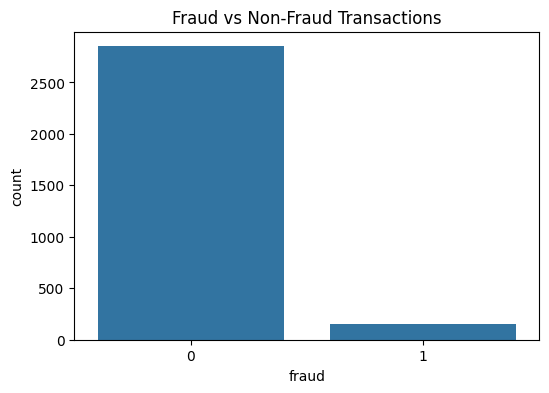

In [7]:
plt.figure(figsize=(6,4))
sns.countplot(x='fraud', data=df)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()


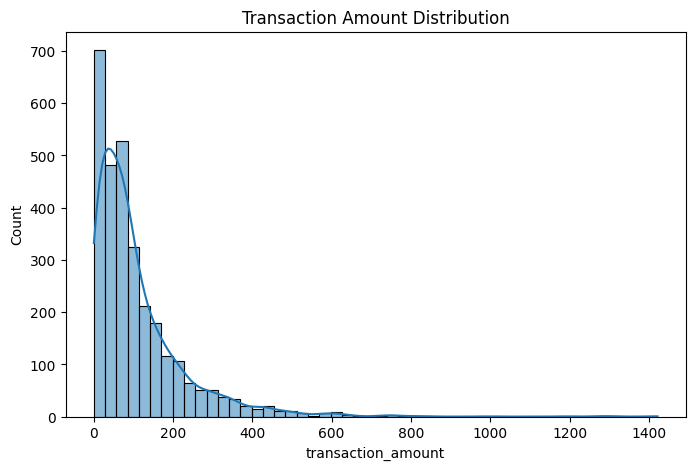

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['transaction_amount'], bins=50, kde=True)
plt.title("Transaction Amount Distribution")
plt.show()


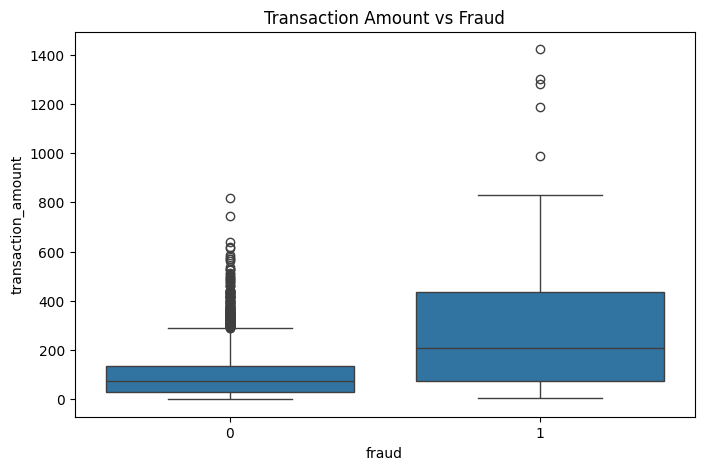

In [9]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud', y='transaction_amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()


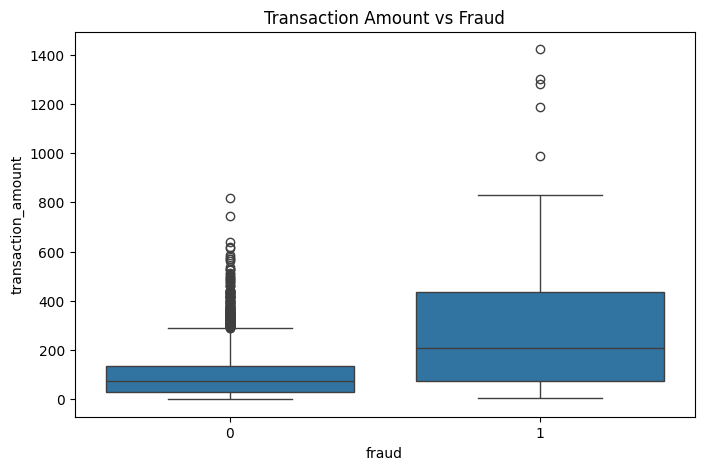

In [10]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud', y='transaction_amount', data=df)
plt.title("Transaction Amount vs Fraud")
plt.show()


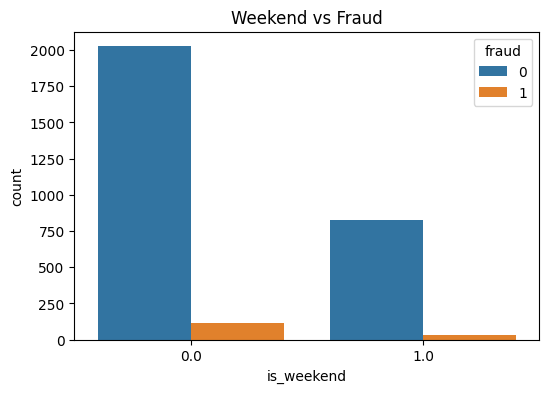

In [11]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_weekend', hue='fraud', data=df)
plt.title("Weekend vs Fraud")
plt.show()


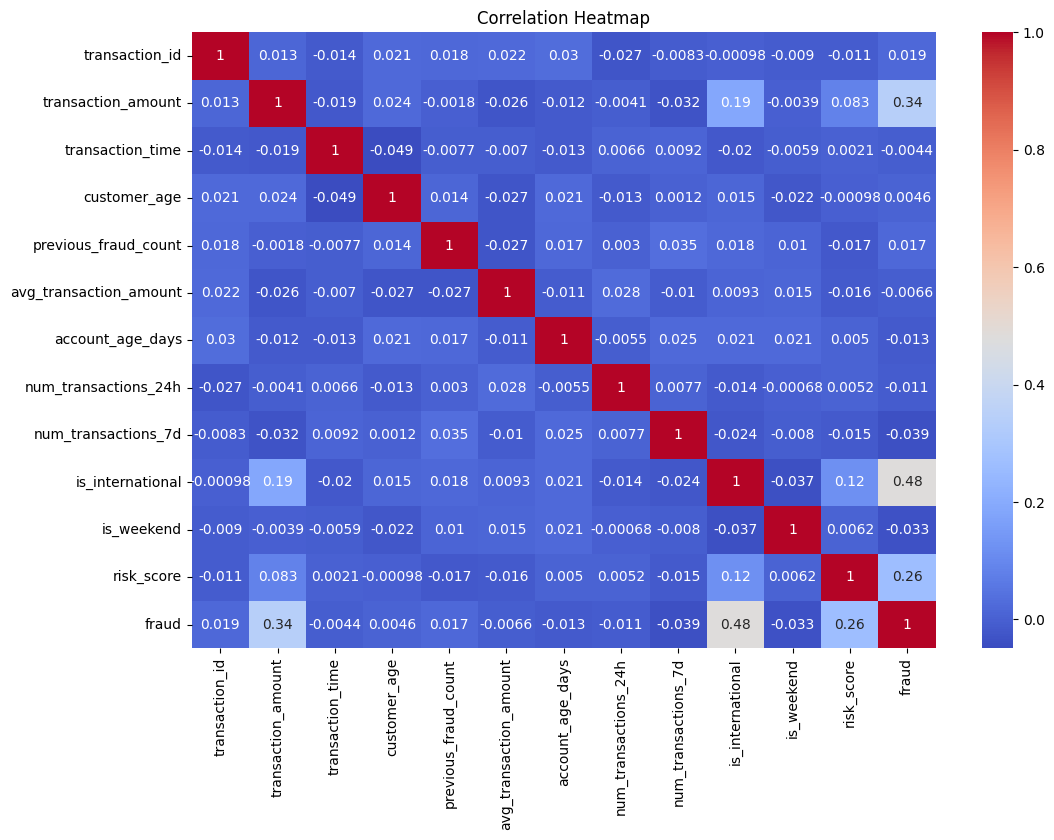

In [12]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()


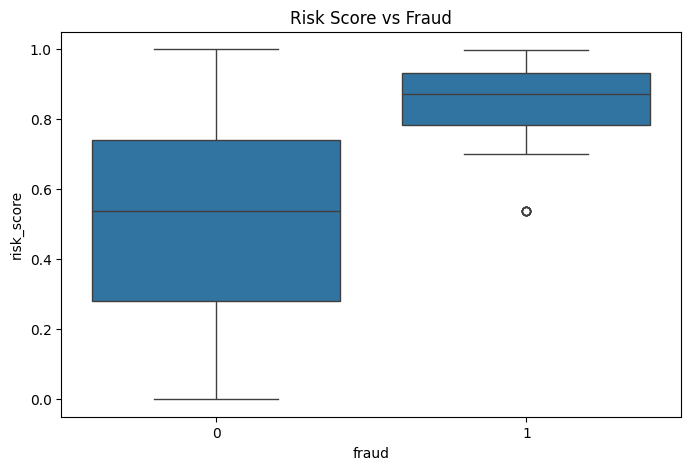

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(x='fraud', y='risk_score', data=df)
plt.title("Risk Score vs Fraud")
plt.show()


In [14]:
df.head()

,transaction_id,transaction_amount,transaction_time,merchant_category,customer_age,customer_location,device_type,card_type,transaction_type,previous_fraud_count,avg_transaction_amount,account_age_days,num_transactions_24h,num_transactions_7d,is_international,is_weekend,risk_score,fraud
0,1,46.93,17266.0,grocery,48.0,city_C,tablet,credit,offline,1.0,90.96,3342.0,2.0,14.0,1.0,0.0,0.816,0
1,2,301.01,86328.0,electronics,58.0,city_A,tablet,debit,offline,0.0,126.38,3157.0,4.0,20.0,0.0,1.0,0.173,0
2,3,131.67,85988.0,grocery,24.0,city_A,desktop,debit,online,0.0,187.89,1163.0,4.0,14.0,0.0,0.0,0.378,0
3,4,91.29,43526.0,travel,40.0,city_A,mobile,credit,offline,0.0,84.32,3150.0,4.0,15.0,0.0,0.0,0.847,0
4,5,16.96,11889.0,food,41.0,city_C,tablet,credit,offline,1.0,138.83,1808.0,3.0,15.0,0.0,0.0,0.799,0


In [15]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

import matplotlib.pyplot as plt
import joblib


In [16]:
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    encoders[col] = le


In [17]:
X = df.drop(["fraud", "transaction_id"], axis=1)
y = df["fraud"]


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [19]:
scaler = MinMaxScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [20]:
models = {
    "Logistic": LogisticRegression(class_weight="balanced"),
    "DecisionTree": DecisionTreeClassifier(class_weight="balanced"),
    "RandomForest": RandomForestClassifier(class_weight="balanced"),
    "GradientBoost": GradientBoostingClassifier(),
    "SVM": SVC(probability=True, class_weight="balanced")
}


In [21]:
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]

    print(f"\n{name}")
    print(classification_report(y_test, y_pred))

    auc = roc_auc_score(y_test, y_prob)
    print("AUC Score:", auc)

    results[name] = auc



Logistic
              precision    recall  f1-score   support

           0       1.00      0.94      0.97       570
           1       0.45      1.00      0.62        30

    accuracy                           0.94       600
   macro avg       0.72      0.97      0.79       600
weighted avg       0.97      0.94      0.95       600

AUC Score: 0.9885380116959064

DecisionTree
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       570
           1       0.78      0.60      0.68        30

    accuracy                           0.97       600
   macro avg       0.88      0.80      0.83       600
weighted avg       0.97      0.97      0.97       600

AUC Score: 0.7956140350877193

RandomForest
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       570
           1       0.84      0.53      0.65        30

    accuracy                           0.97       600
   macro avg       0.91      0

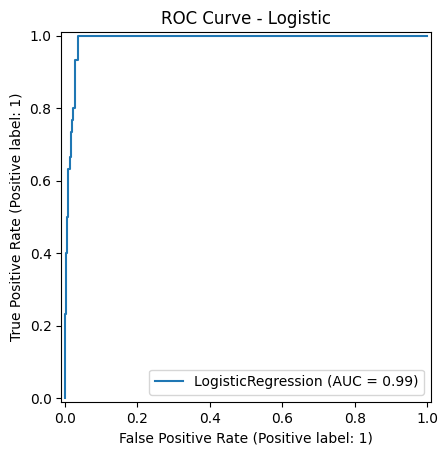

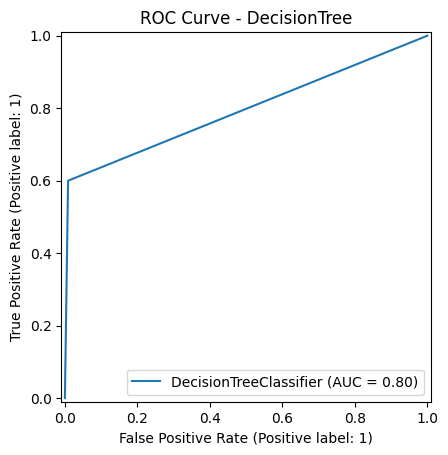

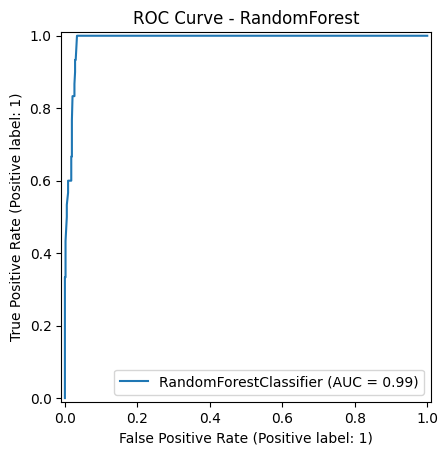

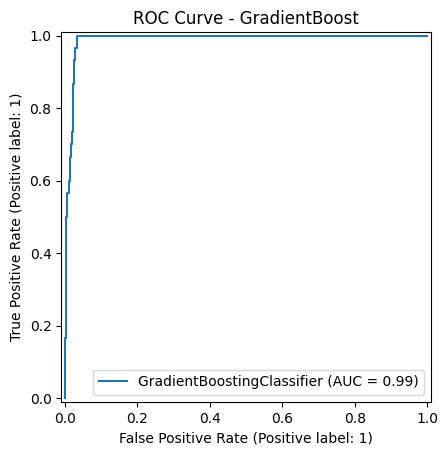

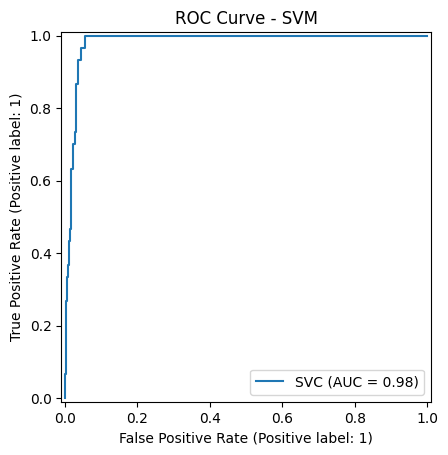

In [22]:
for name, model in models.items():
    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {name}")
    plt.show()


In [23]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20]
}

grid = GridSearchCV(
    RandomForestClassifier(class_weight="balanced"),
    param_grid,
    cv=3,
    scoring="roc_auc"
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_

print("Best Params:", grid.best_params_)


Best Params: {'max_depth': 10, 'n_estimators': 100}


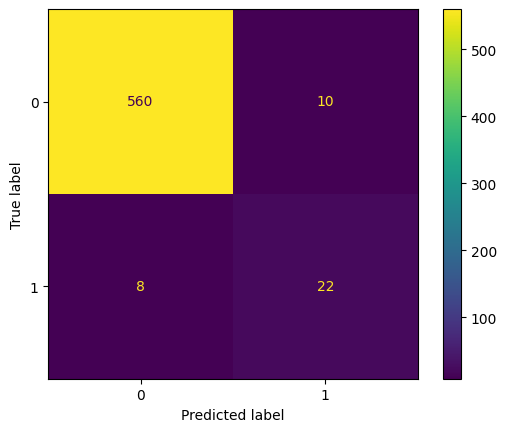

In [24]:
y_pred_best = best_model.predict(X_test)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best)
plt.show()


In [25]:
joblib.dump(best_model, "best_model.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(encoders, "encoders.pkl")


['encoders.pkl']